# PdO on Al₂O₃ — XRD crystallinity of the Batch-1 Sobol films (delivery 2026-08-27)

The fab team sent θ–2θ XRD patterns for the **14 valid Batch-1 conditions × 3 replicates** of the
Experiment02 Sobol design on sapphire (`raw_data_received/08_27_26/PdO_data_0827.xlsx`, sheet `sobol`,
sample IDs `replicate_run`), plus the #14 recipe at 9/11/13 nm on HfO₂/Si (`scaling thickness`), the old
5 nm recipe (`old_recipe`) and the Hall data of every film (`benchmark`). Their slides describe crystallinity
qualitatively — *"25 °C films stay amorphous up to 12 nm, 425 °C films up to 4 nm; #15 shows low
crystallinity"* — and the request was a **% crystallinity per film** that can be modelled.

This notebook documents, step by step, what is being done and why:

1. **What was delivered** — sheets, IDs, the design conditions behind each film.
2. **What the patterns contain** — a ≤ 16 nm film on a single crystal: the substrate *is* the pattern.
3. **Why the textbook degree of crystallinity, crystalline / (crystalline + amorphous), cannot be
   measured here** — the "amorphous halo" that survives substrate subtraction is a scan artefact.
4. **The metric used instead** — a *relative PdO(101) crystallinity index* (and its thickness-normalised
   form), how each number is computed by `utils/xrd_crystallinity.py`.
5. **Results per design condition**, with replicate noise (SEM²) for the GP, checked against the slide claims.
6. **The other sheets** — HfO₂ pieces (Si(200) line removal, pinned reference) and the old recipe.
7. **Crystallinity vs Hall mobility / carrier concentration** — the trade-off the campaign optimises.
8. **Export** of the campaign tables and the findings.

Everything numeric comes from `utils/xrd_crystallinity.py`; the CLI call at the end regenerates the same
files (`output/experiment02_xrd_crystallinity/`).

In [1]:
import os, sys, io, contextlib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Image, display
warnings.filterwarnings('ignore')

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from utils import xrd_crystallinity as xc

XLSX = 'raw_data_received/08_27_26/PdO_data_0827.xlsx'
RUN_TABLE = 'Processed_data_inputs/experiment02/raw_data_update_05_22_2026.xlsx'
OUT_DIR = 'output/experiment02_xrd_crystallinity'
os.makedirs(OUT_DIR, exist_ok=True)
P = xc.PALETTE; xc._style()
BLUE, ORANGE, MUTED = P['series'][0], P['series'][1], P['muted']
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
print('Outputs ->', OUT_DIR)

Outputs -> output/experiment02_xrd_crystallinity


## 1. What was delivered

Every sheet stores one film per **pair of columns** (2θ, intensity) with the film name above the intensity
column. `xc.read_xrd_sheet` returns `{name: (2θ, I)}`; `xc.parse_sample_name` turns `02_14` into
(run 14, replicate 2) and `#14_9nm` into (run 14, 9 nm). The design factors of each run come from the
Batch-1 run table in `Processed_data_inputs/experiment02/`; final PdO thickness = deposited Pd × 5/3
(oxidation expansion measured in the thickness study).

In [2]:
sheets = {s: xc.read_xrd_sheet(XLSX, s) for s in ['sobol', 'scaling thickness', 'old_recipe']}
for s, pats in sheets.items():
    tt = next(iter(pats.values()))[0]
    print(f"{s:18s} {len(pats):3d} patterns   2θ {tt.min():.1f}–{tt.max():.1f}°, step {np.median(np.diff(tt)):.4f}°   e.g. {list(pats)[:3]}")
sob = sheets['sobol']

ids = pd.DataFrame([dict(sample=k, **dict(zip(['run', 'replicate', 'thickness_from_name'], xc.parse_sample_name(k))))
                    for k in sob if k != 'sapphire'])
run_tab = pd.read_excel(RUN_TABLE).drop_duplicates('Base_Run_ID').rename(columns={'Base_Run_ID': 'run'})
cond = ids.merge(run_tab, on='run')[['run'] + xc.FACTOR_COLS].drop_duplicates('run').sort_values('run')
cond['final thickness (nm)'] = (cond['Dep Thickness (nm)'] * 5 / 3).round(1)
temp_of = cond.set_index('run')['Dep Temp (°C)']
print(f"\n{ids.run.nunique()} design conditions × {ids.groupby('run').size().unique().tolist()} replicates = {len(ids)} films "
      f"(the 14 Batch-1 conditions that did not contact-fail; 02_14 contact-failed in Hall but was still scanned)")
cond.set_index('run')

sobol               43 patterns   2θ 20.7–80.6°, step 0.0217°   e.g. ['01_02', '01_03', '01_05']
scaling thickness    3 patterns   2θ 20.5–80.5°, step 0.0217°   e.g. ['#14_9nm', '#14_11nm', '#14_13nm']
old_recipe           2 patterns   2θ 20.0–80.0°, step 0.0100°   e.g. ['sapphire', 'old_recipe']

14 design conditions × [3] replicates = 42 films (the 14 Batch-1 conditions that did not contact-fail; 02_14 contact-failed in Hall but was still scanned)


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),final thickness (nm)
run,,,,,,,,,,,
2,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,8.5
3,40,9.1,3.4,425,262.5,0.02,71.7,400.0,57.9,2.2,3.7
5,19,7.0,8.5,25,661.6,1.00,82.5,288.6,31.0,3.5,5.8
7,23,1.6,7.3,25,364.3,0.02,118.0,474.1,117.0,8.6,14.3
8,8,14.2,2.6,425,594.5,1.00,26.1,48.9,14.6,1.7,2.8
9,7,8.7,7.6,425,429.6,1.00,81.0,229.6,42.4,9.6,16.0
12,15,11.3,5.3,25,231.1,1.00,20.3,83.7,3.6,6.9,11.5
14,36,13.4,6.3,425,694.7,0.02,1.1,217.4,29.1,7.8,13.0
15,27,6.0,4.5,25,649.3,0.02,62.7,362.2,46.5,6.2,10.3


## 2. What the patterns contain

A 3–16 nm PdO film on c-plane sapphire. On a log scale the pattern is the substrate: Al₂O₃(0006) at
41.7° (5·10⁵ counts) with its Cu-Kβ and W-Lα ghosts at 37.5° and 39.9°, a further substrate line at
43.9° and one at 80.2°. **The only film feature is PdO(101) at 2θ ≈ 33.9°**, a few hundred counts on a
~600-count background — that is why the fab team, the thickness study and this notebook all look at the
33–35° window.

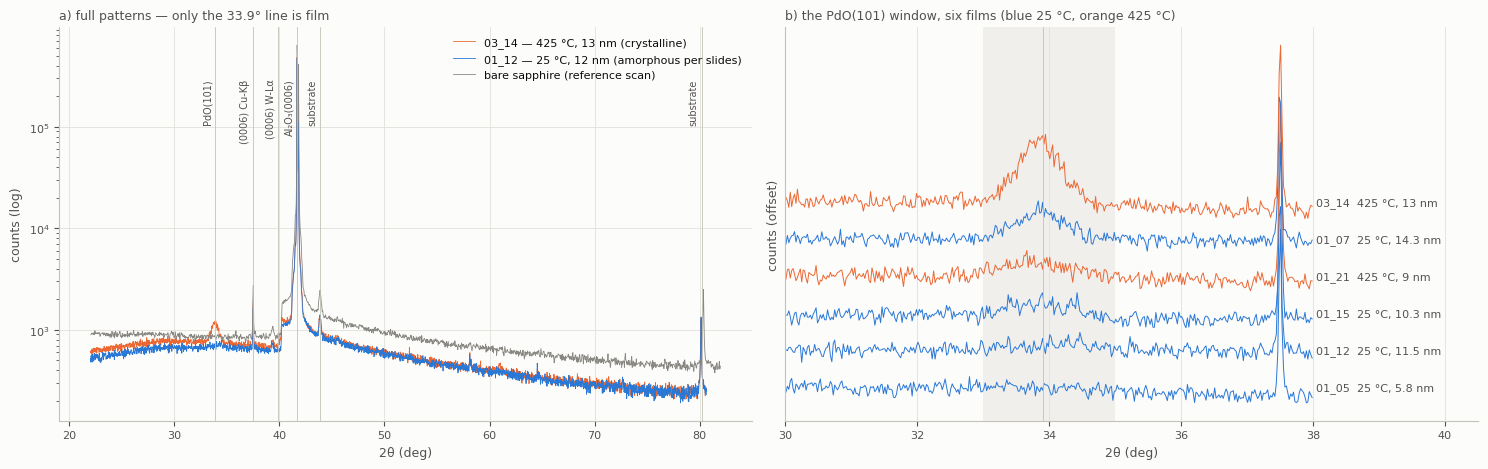

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
for k, c, lab in [('03_14', ORANGE, '03_14 — 425 °C, 13 nm (crystalline)'),
                  ('01_12', BLUE, '01_12 — 25 °C, 12 nm (amorphous per slides)'),
                  ('sapphire', MUTED, 'bare sapphire (reference scan)')]:
    tt, ii = sob[k]; m = (tt > 22) & (tt < 82)
    ax[0].semilogy(tt[m], ii[m], lw=0.6, color=c, label=lab)
for x, lab in [(33.9, 'PdO(101)'), (37.5, '(0006) Cu-Kβ'), (39.9, '(0006) W-Lα'), (41.7, 'Al₂O₃(0006)'),
               (43.9, 'substrate'), (80.2, 'substrate')]:
    ax[0].axvline(x, color=P['axis'], lw=0.6)
    ax[0].text(x - 0.3, 3e5, lab, rotation=90, fontsize=7, va='top', ha='right', color=P['ink2'])
ax[0].set_xlabel('2θ (deg)'); ax[0].set_ylabel('counts (log)')
ax[0].legend(loc='upper right'); ax[0].set_title('a) full patterns — only the 33.9° line is film', loc='left', color=P['ink2'])

show = ['01_05', '01_12', '01_15', '01_21', '01_07', '03_14']
for n, k in enumerate(show):
    tt, ii = sob[k]; m = (tt > 30) & (tt < 38)
    base = np.median(ii[(tt > 31.5) & (tt < 32.5)])
    run = int(k.split('_')[1]); c = BLUE if temp_of[run] == 25 else ORANGE
    ax[1].plot(tt[m], ii[m] - base + 250 * n, lw=0.7, color=c)
    ax[1].text(38.05, 250 * n, f"{k}  {temp_of[run]:.0f} °C, {cond.set_index('run').loc[run, 'final thickness (nm)']:g} nm",
               fontsize=8, va='center', color=P['ink2'])
ax[1].axvspan(33, 35, color=P['window'], lw=0); ax[1].axvline(33.9, color=P['axis'], lw=0.6)
ax[1].set_xlim(30, 40.5); ax[1].set_xlabel('2θ (deg)'); ax[1].set_ylabel('counts (offset)'); ax[1].set_yticks([])
ax[1].set_title('b) the PdO(101) window, six films (blue 25 °C, orange 425 °C)', loc='left', color=P['ink2'])
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/raw_patterns_overview_0827.png', dpi=170, bbox_inches='tight'); plt.show()

## 3. Why crystalline / (crystalline + amorphous) cannot be measured here

The textbook degree of crystallinity integrates the sharp Bragg peaks (crystalline) and the broad halo
(amorphous) **of the same phase** and takes their ratio. It works when the material's own scattering
dominates the pattern (powders, polymers, thick films). Here the film is < 2 % of the counts, so the
amorphous-PdO halo would have to be extracted by subtracting the bare-substrate scan. We try exactly that
below and test whether what is left behaves like film:

* scale the bare sapphire scan onto each film pattern by least squares on the peak-free 22–60° region
  (`xc.scale_reference`), subtract it, and average the residual over the films the fab team calls
  amorphous (25 °C ≤ 12 nm, 425 °C ≤ 4 nm) and over the ones they call crystalline;
* integrate the residual "halo" at 24–40° (peak and ghost windows interpolated across) per film and
  correlate it with film thickness.

A real amorphous-PdO halo must be **larger in the amorphous group** and **grow with thickness**.

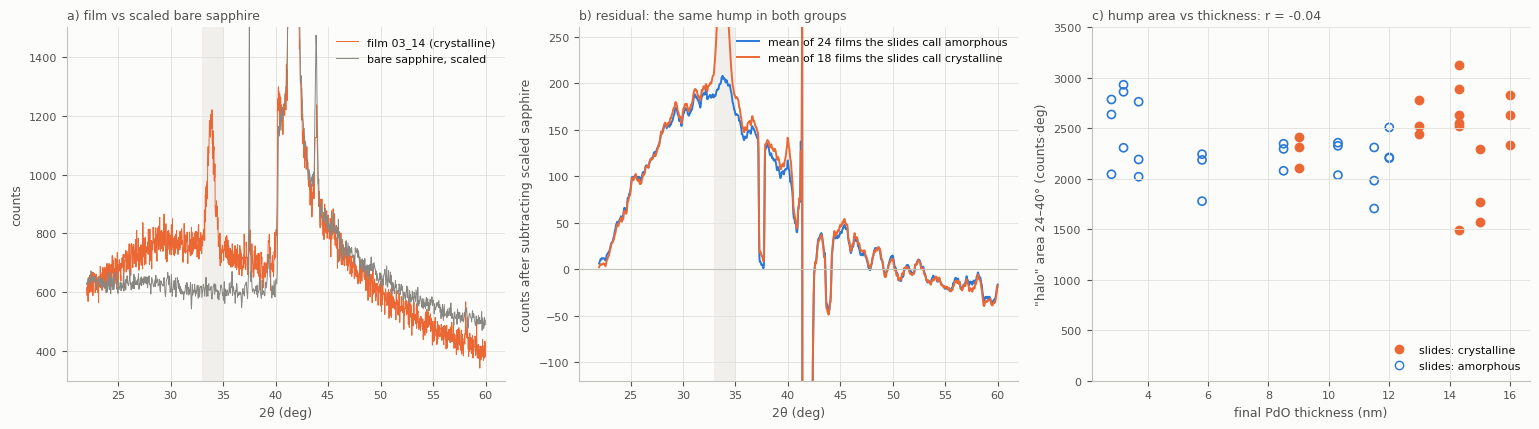

halo area vs thickness: r = -0.04


,n,halo_mean,halo_sd,peak_mean,forced_ratio_pct
slide_amorphous,,,,,
crystalline (slides),18,2401.1,439.1,220.4,8.5
amorphous (slides),24,2296.5,320.3,61.2,2.6


In [4]:
ref = sob['sapphire']
pats = {k: (t, xc.despike(t, i)[0]) for k, (t, i) in sob.items()}          # sharp substrate lines removed
ids['t_final'] = ids.run.map(cond.set_index('run')['final thickness (nm)'])
ids['Dep Temp (°C)'] = ids.run.map(temp_of)
ids['slide_amorphous'] = ((ids['Dep Temp (°C)'] == 25) & (ids.t_final <= 12)) | ((ids['Dep Temp (°C)'] == 425) & (ids.t_final <= 4))

def residual(k):
    tt, ii = pats[k]; a, ri = xc.scale_reference(tt, ii, ref)
    r = ii - a * ri
    return tt, r - np.median(r[(tt > 46) & (tt < 56)]), a

def halo_area(tt, r, lo=24, hi=40):
    m = (tt >= lo) & (tt <= hi)
    excl = ((tt >= 32.8) & (tt <= 35.4)) | ((tt >= 37) & (tt <= 38)) | ((tt >= 39.3) & (tt <= 40))
    rf = r.copy(); rf[excl] = np.interp(tt[excl], tt[m & ~excl], r[m & ~excl])
    return float(np.trapezoid(np.clip(rf[m], 0, None), tt[m]))

rows = []
for k in ids['sample']:
    tt, r, a = residual(k)
    peak = xc.baseline_metrics(*pats[k])['auc_101_net']
    rows.append(dict(sample=k, substrate_scale=a, halo_area=halo_area(tt, r), peak_area=peak))
halo = ids.merge(pd.DataFrame(rows), on='sample')
halo['forced_ratio_pct'] = 100 * halo.peak_area.clip(lower=0) / (halo.peak_area.clip(lower=0) + halo.halo_area)

grid = np.arange(22, 60, 0.0217)
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))
tt, r, a = residual('03_14'); m = (tt > 22) & (tt < 60)
ax[0].plot(tt[m], pats['03_14'][1][m], lw=0.7, color=ORANGE, label='film 03_14 (crystalline)')
ax[0].plot(tt[m], (a * np.interp(tt, *ref) + np.median(pats['03_14'][1][m] - a * np.interp(tt, *ref)[m]))[m], lw=0.7, color=MUTED, label='bare sapphire, scaled')
ax[0].set_ylim(300, 1500); ax[0].axvspan(33, 35, color=P['window'], lw=0); ax[0].set_xlabel('2θ (deg)'); ax[0].set_ylabel('counts')
ax[0].set_title('a) film vs scaled bare sapphire', loc='left', color=P['ink2']); ax[0].legend(loc='upper right')
for flag, c, lab in [(True, BLUE, f'mean of {int(ids.slide_amorphous.sum())} films the slides call amorphous'),
                     (False, ORANGE, f'mean of {int((~ids.slide_amorphous).sum())} films the slides call crystalline')]:
    R = np.mean([np.interp(grid, *residual(k)[:2]) for k in ids.loc[ids.slide_amorphous == flag, 'sample']], axis=0)
    ax[1].plot(grid, np.convolve(R, np.ones(25) / 25, mode='same'), lw=1.4, color=c, label=lab)
ax[1].set_ylim(-120, 260); ax[1].axvspan(33, 35, color=P['window'], lw=0); ax[1].axhline(0, color=P['axis'], lw=0.8)
ax[1].set_xlabel('2θ (deg)'); ax[1].set_ylabel('counts after subtracting scaled sapphire')
ax[1].set_title('b) residual: the same hump in both groups', loc='left', color=P['ink2']); ax[1].legend(loc='upper right')
for flag, c in [(True, BLUE), (False, ORANGE)]:
    s = halo[halo.slide_amorphous == flag]
    ax[2].scatter(s.t_final, s.halo_area, s=34, color=c if not flag else 'none', edgecolor=c, linewidth=1.2)
r_t = np.corrcoef(halo.halo_area, halo.t_final)[0, 1]
ax[2].set_ylim(0, 3500); ax[2].set_xlabel('final PdO thickness (nm)'); ax[2].set_ylabel('"halo" area 24–40° (counts·deg)')
ax[2].set_title(f'c) hump area vs thickness: r = {r_t:.2f}', loc='left', color=P['ink2'])
ax[2].legend(handles=[Line2D([], [], marker='o', ls='', color=ORANGE, label='slides: crystalline'),
                      Line2D([], [], marker='o', ls='', markerfacecolor='none', color=BLUE, label='slides: amorphous')], loc='lower right')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/diag_amorphous_halo_check_0827.png', dpi=170, bbox_inches='tight'); plt.show()

g = halo.groupby('slide_amorphous').agg(n=('sample', 'size'), halo_mean=('halo_area', 'mean'), halo_sd=('halo_area', 'std'),
                                         peak_mean=('peak_area', 'mean'), forced_ratio_pct=('forced_ratio_pct', 'mean')).round(1)
g.index = g.index.map({True: 'amorphous (slides)', False: 'crystalline (slides)'})
print(f'halo area vs thickness: r = {r_t:.2f}')
g

**Verdict.** The residual hump is the same in both groups, and its area does not depend on film thickness
(r ≈ 0), while the PdO(101) peak area differs by ~3× between the groups. A film signal cannot behave like
that: the hump is a **scan-geometry artefact** (bare wafer vs coated pieces: different height/alignment and
a coarser reference step), not amorphous PdO. Forcing the ratio anyway gives a few per cent for every film
with the artefact as denominator — a number, not a crystalline fraction. The amorphous term is simply below
what a θ–2θ scan of a ≤ 16 nm film on sapphire can resolve; grazing-incidence XRD (or a bare piece
scanned in the same session with identical alignment) would be needed to make it measurable.

## 4. What is measured instead: the relative PdO(101) crystallinity index

Because the only film information is the PdO(101) reflection, the crystallinity number is built on it,
consistently with the campaign objective already defined in the thickness study ("XRD 33–35° AUC ↓").
For each film `utils/xrd_crystallinity.py` does:

1. **Despike** — a 0.4° running median removes sharp single-crystal lines (needed for the Si(200) line
   at 33.0° on the HfO₂/Si pieces); the 0.8–1.5° wide PdO peak is untouched.
2. **Baseline area** — linear baseline through the flanks 31.5–32.5° and 35.5–36.5°; `auc_101_net` is the
   *unclipped* integral of (data − baseline) over 33–35° (unbiased, zero-mean for an empty window;
   `auc_101` is the clipped legacy version).
3. **Peak fit** — Gaussian + linear background on 31.5–36.5° with centre ∈ [33.2, 34.8]° and FWHM ∈
   [0.12, 2.5]°: gives `fit_center`, `fit_fwhm`, `fit_area`, the apparent Scherrer size and a robust
   `snr_fit` = amplitude / MAD-residual. **`peak_detected`** = SNR ≥ 3 with a FWHM strictly inside the band.
4. **Index** —
   `crystallinity_pct = 100 · auc_101_net / ref_area`, with `ref_area` = mean of the three largest detected
   areas in the sheet (`--ref top3`; pin a number to compare deliveries);
   `crystallinity_pct_thk = 100 · (auc_101_net / t_final) / ref_per_nm` (NaN when no peak is detected)
   — the thickness-normalised form is the closest proxy for a crystalline *fraction*, since a Bragg area
   scales with crystalline volume × thickness.

Two films side by side show the mechanics:

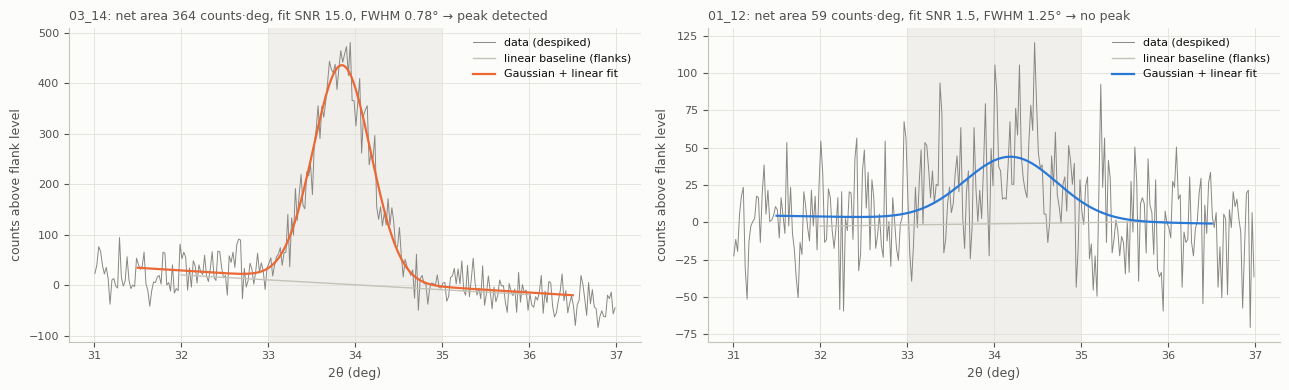

In [5]:
cfg = xc.DEFAULT_CFG
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, k in zip(ax, ['03_14', '01_12']):
    tt, ii = pats[k]
    bm = xc.baseline_metrics(tt, ii, cfg); fp = xc.fit_peak(tt, ii, cfg)
    m = (tt > 31) & (tt < 37)
    lvl = np.median(ii[((tt > 31.5) & (tt < 32.5)) | ((tt > 35.5) & (tt < 36.5))])
    a.plot(tt[m], ii[m] - lvl, lw=0.7, color=MUTED, label='data (despiked)')
    # baseline through the flank medians
    x1, x2 = 32.0, 36.0; y1 = np.median(ii[(tt > 31.5) & (tt < 32.5)]); y2 = np.median(ii[(tt > 35.5) & (tt < 36.5)])
    a.plot([x1, x2], [y1 - lvl, y2 - lvl], lw=1, color=P['axis'], label='linear baseline (flanks)')
    x = np.linspace(31.5, 36.5, 300); s = fp['fit_fwhm'] / xc.FWHM_PER_SIGMA
    mm = (tt >= 31.5) & (tt <= 36.5); gauss = np.exp(-0.5 * ((tt[mm] - fp['fit_center']) / s) ** 2)
    coef, *_ = np.linalg.lstsq(np.column_stack([np.ones(mm.sum()), tt[mm] - 34, gauss]), ii[mm], rcond=None)
    a.plot(x, coef[0] + coef[1] * (x - 34) + coef[2] * np.exp(-0.5 * ((x - fp['fit_center']) / s) ** 2) - lvl, lw=1.6,
           color=ORANGE if fp['snr_fit'] >= 3 else BLUE, label='Gaussian + linear fit')
    a.axvspan(33, 35, color=P['window'], lw=0)
    a.set_title(f"{k}: net area {bm['auc_101_net']:.0f} counts·deg, fit SNR {fp['snr_fit']:.1f}, FWHM {fp['fit_fwhm']:.2f}°"
                f" → {'peak detected' if fp['snr_fit'] >= 3 else 'no peak'}", loc='left', color=P['ink2'], fontsize=9)
    a.set_xlabel('2θ (deg)'); a.set_ylabel('counts above flank level'); a.legend(loc='upper right')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/metric_demo_0827.png', dpi=170, bbox_inches='tight'); plt.show()

In [6]:
# the full pipeline on the sobol sheet
df = xc.analyze_sheet(XLSX, 'sobol', keep_patterns=True)          # despike → baseline area → fit → detection
df = xc.attach_run_table(df, RUN_TABLE)                             # design factors + final thickness
df, refs = xc.add_crystallinity(df, ref='top3')                     # % of the top-3 reference (per sheet)
runs = xc.summarize_by_run(df)
print('reference used for 100 %:'); display(refs.round(2))
cols = ['sample', 'run', 'replicate', 'Dep Temp (°C)', 'thickness_final_nm', 'auc_101_net', 'snr_fit', 'fit_fwhm',
        'scherrer_nm', 'peak_detected', 'crystallinity_pct', 'crystallinity_pct_thk']
print(f'{int(df.peak_detected.sum())} of {len(df)} films have a resolved PdO(101) peak')
df[cols].sort_values(['Dep Temp (°C)', 'thickness_final_nm', 'replicate']).round(2).reset_index(drop=True)

[sobol] substrate scan 'sapphire': window SNR 0.4 (fit SNR 0.6) -> not subtracted (flat in the objective window)


reference used for 100 %:


,group,area_col,ref_spec,ref_area,ref_area_per_nm
0,sobol,auc_101_net,top3,333.93,23.88


19 of 42 films have a resolved PdO(101) peak


,sample,run,replicate,Dep Temp (°C),thickness_final_nm,auc_101_net,snr_fit,fit_fwhm,scherrer_nm,peak_detected,crystallinity_pct,crystallinity_pct_thk
0,01_19,19,1,25,3.17,48.11,1.44,2.50,3.32,False,14.41,NaN
1,02_19,19,2,25,3.17,32.44,0.54,1.43,5.80,False,9.71,NaN
2,03_19,19,3,25,3.17,48.51,1.17,2.42,3.43,False,14.53,NaN
3,01_05,5,1,25,5.83,32.76,1.26,2.50,3.32,False,9.81,NaN
4,02_05,5,2,25,5.83,47.89,1.31,2.50,3.33,False,14.34,NaN
5,03_05,5,3,25,5.83,30.72,0.84,1.83,4.54,False,9.20,NaN
6,01_02,2,1,25,8.50,69.05,1.42,1.39,5.99,False,20.68,NaN
7,02_02,2,2,25,8.50,79.95,2.09,1.44,5.77,False,23.94,NaN
8,03_02,2,3,25,8.50,60.06,1.85,1.34,6.19,False,17.99,NaN
9,01_15,15,1,25,10.33,93.06,3.09,1.12,7.42,True,27.87,37.72


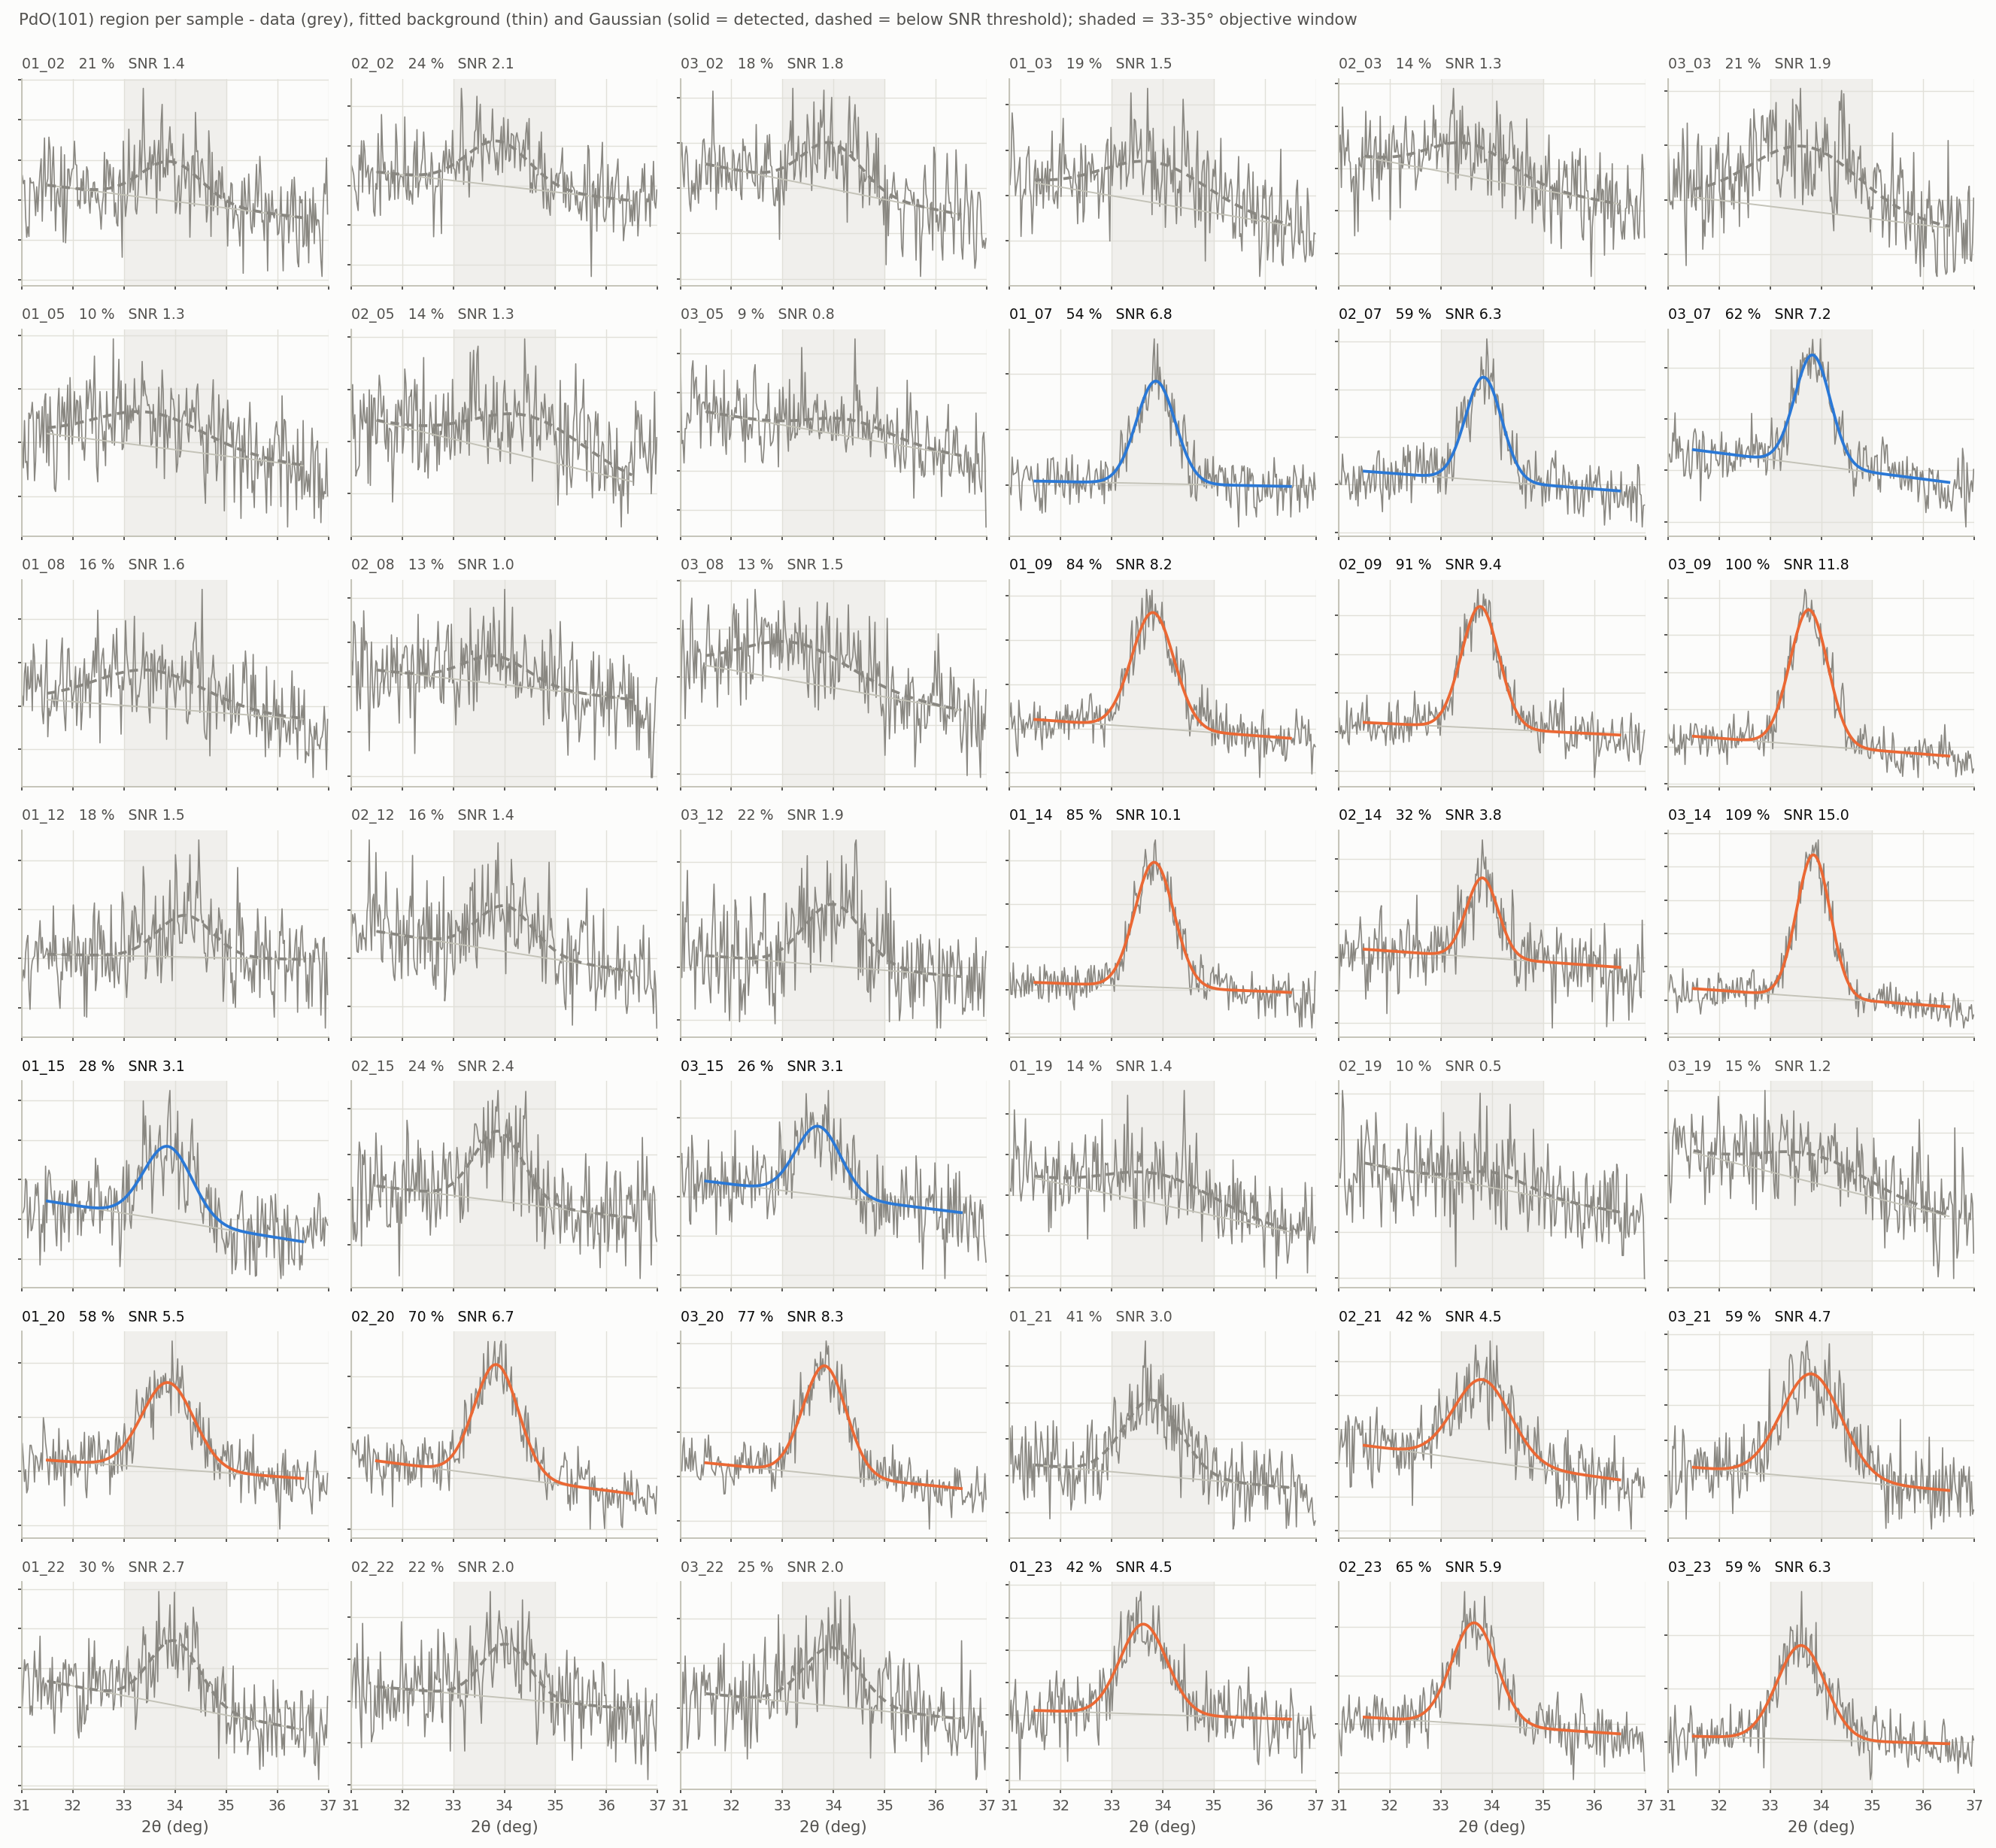

In [7]:
# fit QA: every film, its baseline and Gaussian (solid = detected, dashed = below threshold)
xc.plot_fits(df, f'{OUT_DIR}/pdo101_fits_sobol_0827.png', cfg)
display(Image(f'{OUT_DIR}/pdo101_fits_sobol_0827.png', width=1400))

**Reading the numbers.** Films with a resolved peak have FWHM 0.8–1.1° (apparent crystallite 8–10 nm, i.e.
the film thickness — no instrumental correction, so a lower bound). Films *without* a resolved peak still
return 10–25 %: the panels show a genuine broad, weak (101) bump (FWHM 1.2–1.5°) that grows with thickness
— nano-crystalline PdO just below detection — plus the noise floor. Read those values as "below detection",
not as a measured fraction; `peak_detected` carries that distinction into the tables.

## 5. Results per design condition

Replicates are averaged per condition; `*_sem2` = replicate variance / n is the observation-noise term the
campaign GP takes as `train_Yvar` (same convention as the Hall responses). FWHM / Scherrer statistics use
detected peaks only.

In [8]:
rcols = ['run', 'Dep Temp (°C)', 'thickness_final_nm', 'n', 'n_detected', 'crystallinity_pct_mean', 'crystallinity_pct_sd',
         'crystallinity_pct_sem2', 'crystallinity_pct_thk_mean', 'auc_101_net_mean', 'fit_fwhm_mean', 'scherrer_nm_mean']
runs[rcols].sort_values(['Dep Temp (°C)', 'thickness_final_nm']).round(2).reset_index(drop=True)

,run,Dep Temp (°C),thickness_final_nm,n,n_detected,crystallinity_pct_mean,crystallinity_pct_sd,crystallinity_pct_sem2,crystallinity_pct_thk_mean,auc_101_net_mean,fit_fwhm_mean,scherrer_nm_mean
0,19,25,3.17,3,0,12.88,2.74,2.51,NaN,43.02,NaN,NaN
1,5,25,5.83,3,0,11.12,2.81,2.63,NaN,37.12,NaN,NaN
2,2,25,8.50,3,0,20.87,2.98,2.97,NaN,69.69,NaN,NaN
3,15,25,10.33,3,2,25.86,1.97,1.29,36.30,86.35,1.08,7.73
4,12,25,11.50,3,0,18.46,3.00,3.00,NaN,61.65,NaN,NaN
5,22,25,12.00,3,0,25.52,3.93,5.15,NaN,85.21,NaN,NaN
6,7,25,14.33,3,3,58.24,3.80,4.83,56.83,194.48,0.85,9.78
7,8,425,2.83,3,0,13.73,1.91,1.21,NaN,45.84,NaN,NaN
8,3,425,3.67,3,0,18.08,3.92,5.11,NaN,60.37,NaN,NaN
9,21,425,9.00,3,2,47.21,10.33,35.55,78.20,157.65,1.34,6.18


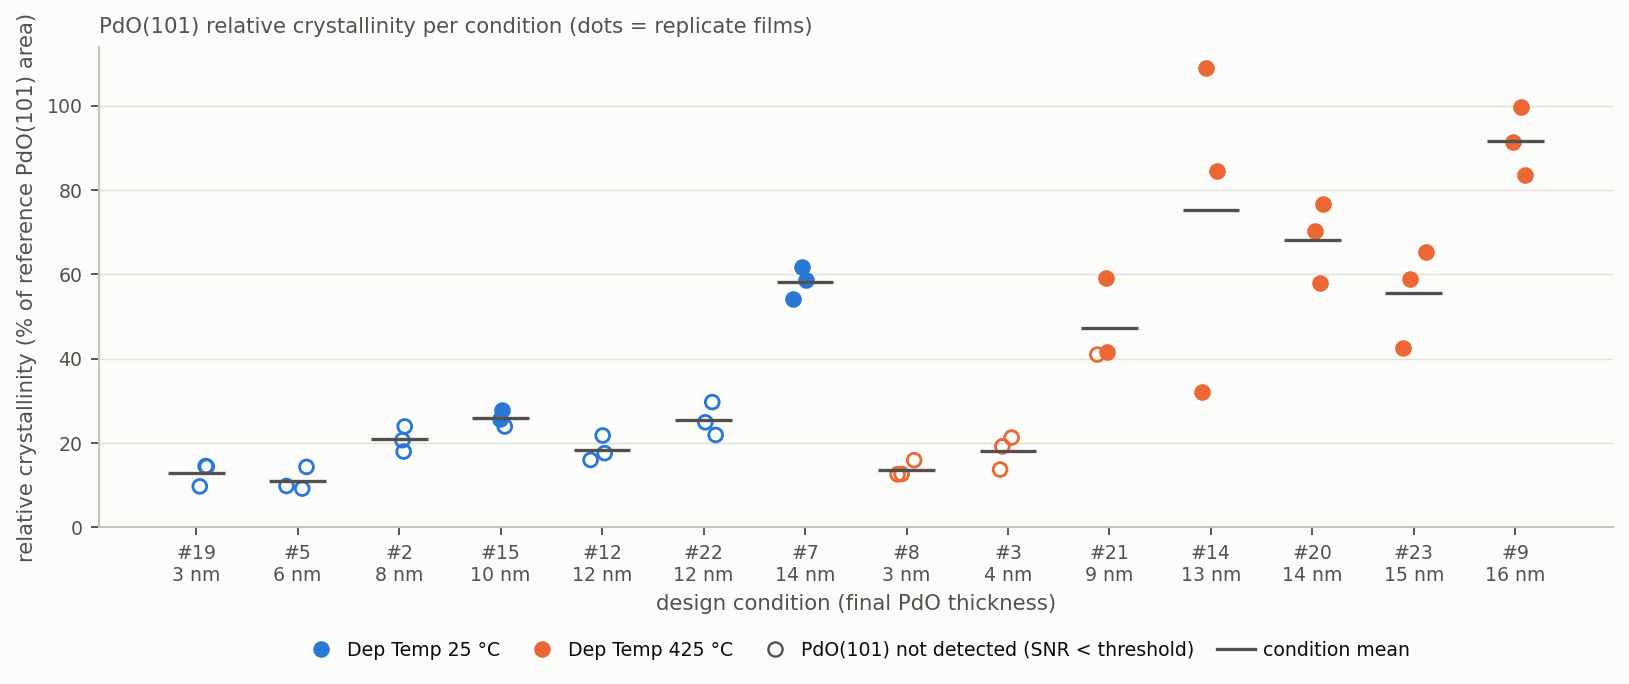

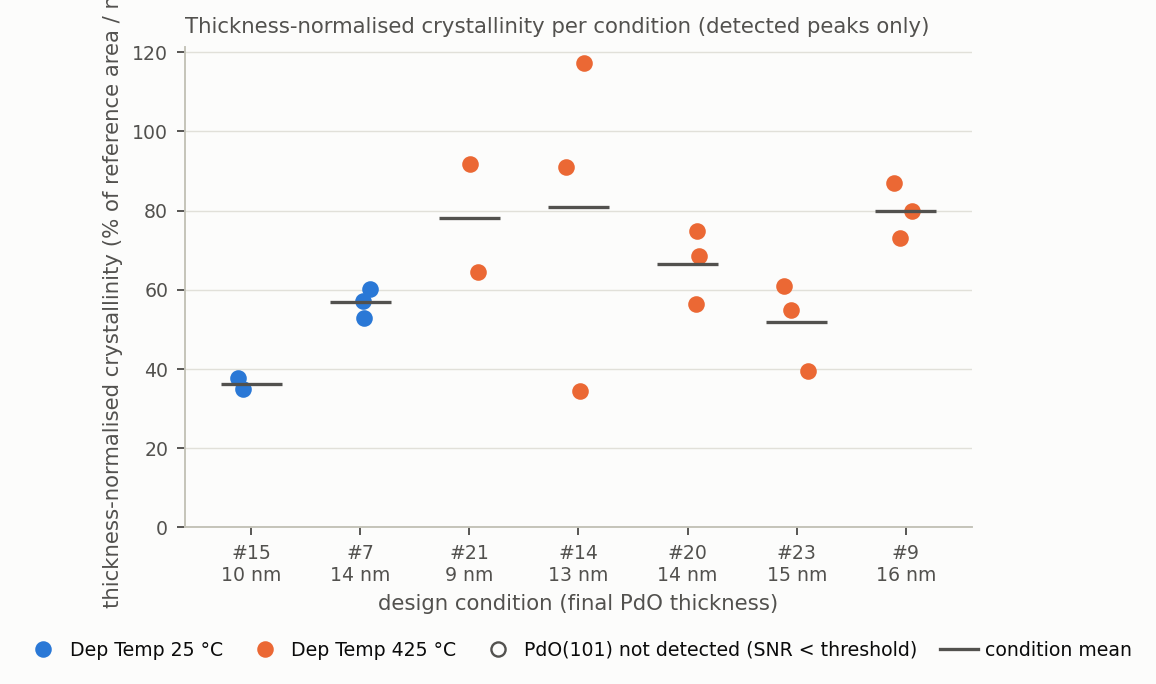

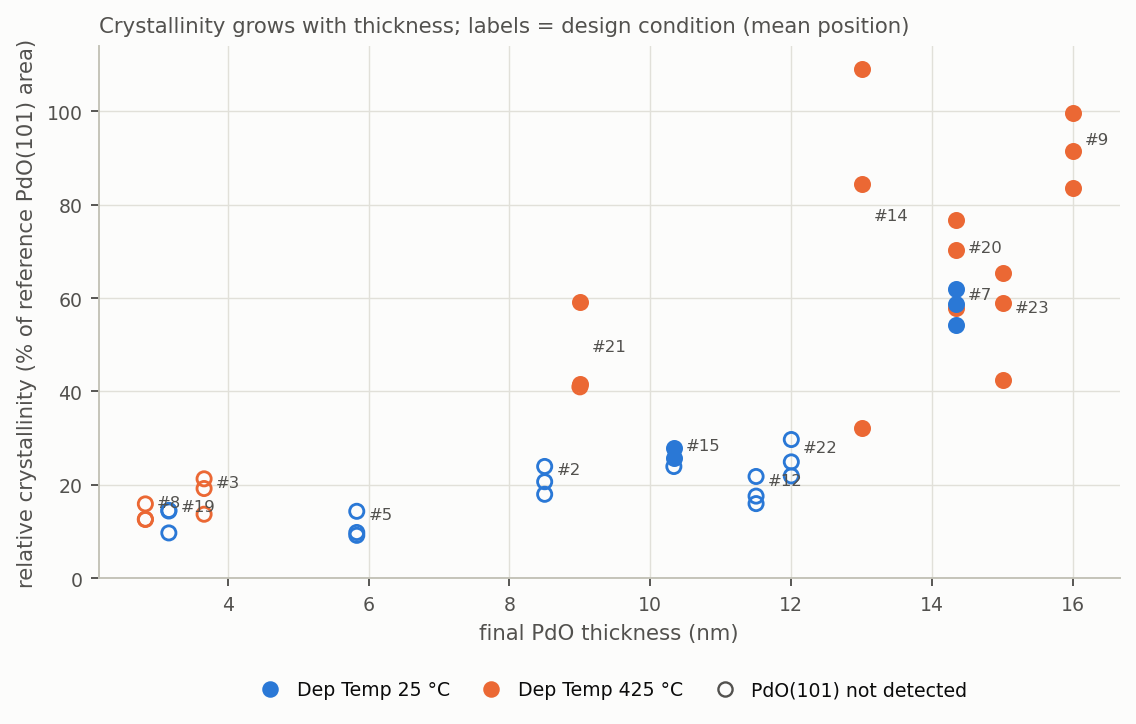

In [9]:
xc.plot_by_run(df, f'{OUT_DIR}/crystallinity_by_run_0827.png')
xc.plot_by_run(df, f'{OUT_DIR}/crystallinity_thk_by_run_0827.png', ycol='crystallinity_pct_thk')
xc.plot_vs_thickness(df, f'{OUT_DIR}/crystallinity_vs_thickness_0827.png')
display(Image(f'{OUT_DIR}/crystallinity_by_run_0827.png', width=1000))
display(Image(f'{OUT_DIR}/crystallinity_thk_by_run_0827.png', width=800))
display(Image(f'{OUT_DIR}/crystallinity_vs_thickness_0827.png', width=800))

**Check against the slide claims** — "25 °C films remain amorphous when ≤ 12 nm, 425 °C films when ≤ 4 nm":

In [10]:
chk = df.merge(ids[['sample', 'slide_amorphous']], on='sample')
tab = pd.crosstab(chk.slide_amorphous.map({True: 'slides: amorphous', False: 'slides: crystalline'}),
                  chk.peak_detected.map({True: 'PdO(101) detected', False: 'no peak'}))
display(tab)
print('films the slides call amorphous but that show a (weak) peak:',
      chk.loc[chk.slide_amorphous & chk.peak_detected, ['sample', 'snr_fit', 'crystallinity_pct']].round(2).to_dict('records'))
print('films the slides call crystalline without a resolved peak:',
      chk.loc[~chk.slide_amorphous & ~chk.peak_detected, ['sample', 'snr_fit', 'crystallinity_pct']].round(2).to_dict('records'))
r14 = df[df.run == 14][['sample', 'crystallinity_pct', 'snr_fit']].round(1)
print('\ncondition #14 replicates (02_14 was the contact-fail film in Hall):'); display(r14)

peak_detected,PdO(101) detected,no peak
slide_amorphous,,
slides: amorphous,2,22
slides: crystalline,17,1


films the slides call amorphous but that show a (weak) peak: [{'sample': '01_15', 'snr_fit': 3.09, 'crystallinity_pct': 27.87}, {'sample': '03_15', 'snr_fit': 3.06, 'crystallinity_pct': 25.78}]
films the slides call crystalline without a resolved peak: [{'sample': '01_21', 'snr_fit': 2.98, 'crystallinity_pct': 40.98}]

condition #14 replicates (02_14 was the contact-fail film in Hall):


,sample,crystallinity_pct,snr_fit
7,01_14,84.5,10.1
21,02_14,32.1,3.8
35,03_14,108.9,15.0


## 6. The other sheets

* **`scaling thickness`** — the #14 recipe at 9 / 11 / 13 nm final on HfO₂/Si. The Si(001) substrate adds the
  forbidden Si(200) line at 33.0°, inside the objective window; the despiking step removes it. Scan step
  and count level match the sobol sheet, so the sobol reference (area and area/nm) is **pinned** to make the
  percentages comparable — an assumption to keep in mind.
* **`old_recipe`** — one 5 nm film plus its own sapphire scan, measured with different settings (0.01° step,
  10× counts). Its sapphire shows sharp artefacts at 33.4° and 34.4°; after despiking neither the reference
  nor the film shows a feature in the window. With a single film there is no meaningful within-sheet
  reference, so only absolute metrics are reported.

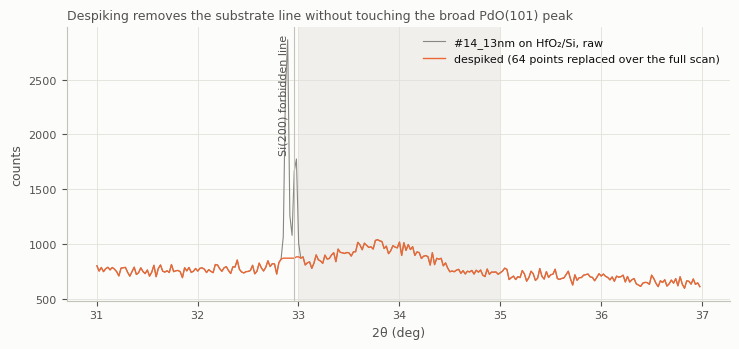

HfO₂ pieces (sobol reference pinned):


,sample,thickness_final_nm,n_despiked,auc_101_net,snr_fit,fit_fwhm,peak_detected,crystallinity_pct,crystallinity_pct_thk
0,#14_9nm,9.0,61,154.72,3.40,1.92,True,46.33,72.00
1,#14_11nm,11.0,63,281.05,6.40,1.62,True,84.17,107.02
2,#14_13nm,13.0,64,288.84,6.55,1.22,True,86.50,93.06


[old_recipe] substrate scan 'sapphire': window SNR 2.4 (fit SNR 0.8) -> not subtracted (flat in the objective window)

old 5 nm recipe (absolute metrics; different instrument settings):


,sample,n_despiked,substrate_subtracted,auc_101_net,noise_sd,snr_fit,fit_fwhm,peak_detected
0,old_recipe,110,False,272.83,139.26,1.28,1.58,False


In [11]:
thk = sheets['scaling thickness']
fig, ax = plt.subplots(figsize=(7.5, 3.6))
tt, ii = thk['#14_13nm']; clean, n = xc.despike(tt, ii); m = (tt > 31) & (tt < 37)
ax.plot(tt[m], ii[m], lw=0.8, color=MUTED, label='#14_13nm on HfO₂/Si, raw')
ax.plot(tt[m], clean[m], lw=1.0, color=ORANGE, label=f'despiked ({n} points replaced over the full scan)')
ax.axvline(32.96, color=P['axis'], lw=0.8); ax.text(32.9, ax.get_ylim()[1] * 0.98, 'Si(200) forbidden line', rotation=90, va='top', ha='right', fontsize=8, color=P['ink2'])
ax.axvspan(33, 35, color=P['window'], lw=0); ax.set_xlabel('2θ (deg)'); ax.set_ylabel('counts'); ax.legend(loc='upper right')
ax.set_title('Despiking removes the substrate line without touching the broad PdO(101) peak', loc='left', color=P['ink2'], fontsize=9)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/hfo2_despike_demo_0827.png', dpi=170, bbox_inches='tight'); plt.show()

hf = xc.analyze_sheet(XLSX, 'scaling thickness', keep_patterns=True, verbose=False)
hf = xc.attach_run_table(hf, RUN_TABLE)
hf, hf_refs = xc.add_crystallinity(hf, ref=float(refs.ref_area[0]), ref_per_nm=float(refs.ref_area_per_nm[0]))
print('HfO₂ pieces (sobol reference pinned):')
display(hf[['sample', 'thickness_final_nm', 'n_despiked', 'auc_101_net', 'snr_fit', 'fit_fwhm', 'peak_detected',
            'crystallinity_pct', 'crystallinity_pct_thk']].round(2))
old = xc.analyze_sheet(XLSX, 'old_recipe', verbose=True)
print('\nold 5 nm recipe (absolute metrics; different instrument settings):')
display(old[['sample', 'n_despiked', 'substrate_subtracted', 'auc_101_net', 'noise_sd', 'snr_fit', 'fit_fwhm', 'peak_detected']].round(2))

## 7. Crystallinity vs the Hall responses

The campaign's objectives are Hall mobility ↑, carrier concentration ↓ and crystallinity ↓ (amorphous PdO
is the target). The `benchmark` sheet lists mobility and carrier concentration per film (row = carrier
concentration, the film's mobility sits in its own column), so the trade-off can be looked at directly on
the same 41 films (02_14 contact-failed).

41 of 42 films have Hall data

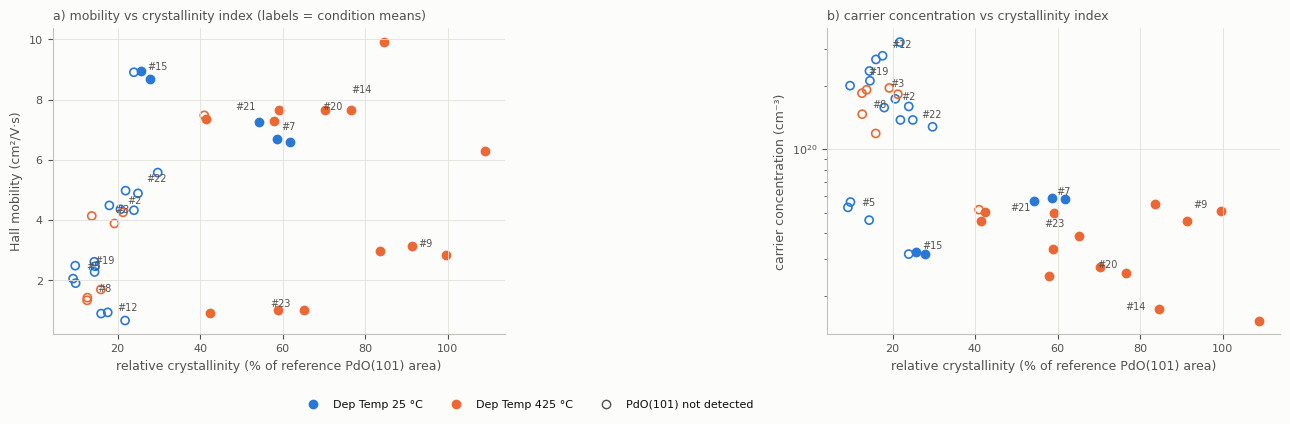

condition-level Spearman ρ (n = 14): crystallinity vs mobility +0.52 (p = 0.06), vs log10 carrier -0.70 (p = 0.01)


In [12]:
raw = pd.read_excel(XLSX, sheet_name='benchmark', header=None)
hdr, body = raw.iloc[0].tolist(), raw.iloc[1:]
hall = []
for j in range(1, raw.shape[1]):
    col = pd.to_numeric(body.iloc[:, j], errors='coerce')
    for i in body.index[col.notna().values]:
        hall.append(dict(sample=str(hdr[j]).strip(), mobility=float(body.loc[i, j]), carrier=float(body.loc[i, 0])))
hall = pd.DataFrame(hall)
xh = df.merge(hall, on='sample', how='left')
print(f'{int(xh.mobility.notna().sum())} of {len(xh)} films have Hall data')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for T, c in [(25, BLUE), (425, ORANGE)]:
    s = xh[(xh['Dep Temp (°C)'] == T) & xh.mobility.notna()]
    for a, y in zip(ax, ['mobility', 'carrier']):
        det = s.peak_detected.astype(bool)
        a.scatter(s.crystallinity_pct[det], s[y][det], s=34, color=c, edgecolor=c, linewidth=1.2)
        a.scatter(s.crystallinity_pct[~det], s[y][~det], s=34, color='none', edgecolor=c, linewidth=1.2)
cm = xh.groupby('run').agg(x=('crystallinity_pct', 'mean'), mob=('mobility', 'mean'), car=('carrier', 'mean'))
for r, row in cm.iterrows():
    ax[0].annotate(f'#{int(r)}', (row.x, row.mob), xytext=(4, 3), textcoords='offset points', fontsize=7, color=P['ink2'])
    ax[1].annotate(f'#{int(r)}', (row.x, row.car), xytext=(4, 3), textcoords='offset points', fontsize=7, color=P['ink2'])
ax[0].set_ylabel('Hall mobility (cm²/V·s)'); ax[1].set_ylabel('carrier concentration (cm⁻³)'); ax[1].set_yscale('log')
for a in ax:
    a.set_xlabel('relative crystallinity (% of reference PdO(101) area)')
ax[0].set_title('a) mobility vs crystallinity index (labels = condition means)', loc='left', color=P['ink2'], fontsize=9)
ax[1].set_title('b) carrier concentration vs crystallinity index', loc='left', color=P['ink2'], fontsize=9)
handles = [Line2D([], [], marker='o', ls='', color=BLUE, label='Dep Temp 25 °C'), Line2D([], [], marker='o', ls='', color=ORANGE, label='Dep Temp 425 °C'),
           Line2D([], [], marker='o', ls='', markerfacecolor='none', color=P['ink2'], label='PdO(101) not detected')]
ax[0].legend(handles=handles, loc='upper center', bbox_to_anchor=(1.05, -0.18), ncol=3)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/crystallinity_vs_hall_0827.png', dpi=170, bbox_inches='tight'); plt.show()

from scipy.stats import spearmanr
cm2 = cm.dropna()
print(f'condition-level Spearman ρ (n = {len(cm2)}): crystallinity vs mobility {spearmanr(cm2.x, cm2.mob)[0]:+.2f} '
      f'(p = {spearmanr(cm2.x, cm2.mob)[1]:.2f}), vs log10 carrier {spearmanr(cm2.x, np.log10(cm2.car))[0]:+.2f} '
      f'(p = {spearmanr(cm2.x, np.log10(cm2.car))[1]:.2f})')

## 8. Export

The CLI regenerates the deliverables from the same code path used above (per-sample / per-run / references /
config sheets and the figures); the notebook adds the Hall merge.

In [13]:
quiet = io.StringIO()
with contextlib.redirect_stdout(quiet):
    xc.main(['--xlsx', XLSX, '--sheet', 'sobol', '--run-table', RUN_TABLE, '--out-dir', OUT_DIR, '--tag', '0827', '--no-figures'])
    xc.main(['--xlsx', XLSX, '--sheet', 'scaling thickness', '--run-table', RUN_TABLE, '--ref', f'{refs.ref_area[0]:.2f}',
             '--ref-per-nm', f'{refs.ref_area_per_nm[0]:.2f}', '--out-dir', OUT_DIR, '--tag', '0827_hfo2_thickness', '--no-figures'])
    xc.main(['--xlsx', XLSX, '--sheet', 'old_recipe', '--out-dir', OUT_DIR, '--tag', '0827_old_recipe', '--no-figures'])
print('\n'.join(l for l in quiet.getvalue().splitlines() if l.startswith('wrote')))

with pd.ExcelWriter(f'{OUT_DIR}/xrd_crystallinity_vs_hall_0827.xlsx') as w:
    xh[cols + ['mobility', 'carrier']].to_excel(w, sheet_name='per_sample', index=False)
    runs.merge(xh.groupby('run').agg(mobility_mean=('mobility', 'mean'), carrier_mean=('carrier', 'mean')).reset_index(),
               on='run').to_excel(w, sheet_name='per_run', index=False)
    halo.round(2).to_excel(w, sheet_name='halo_check', index=False)
print(f'wrote {OUT_DIR}/xrd_crystallinity_vs_hall_0827.xlsx')

wrote output/experiment02_xrd_crystallinity/xrd_crystallinity_0827.xlsx
wrote output/experiment02_xrd_crystallinity/xrd_crystallinity_0827_hfo2_thickness.xlsx
wrote output/experiment02_xrd_crystallinity/xrd_crystallinity_0827_old_recipe.xlsx
wrote output/experiment02_xrd_crystallinity/xrd_crystallinity_vs_hall_0827.xlsx


## 9. Findings

1. **A true degree of crystallinity is not measurable on these films, and that is a property of the
   measurement, not of the analysis.** After subtracting the scaled bare-sapphire scan, the residual hump is
   the same for the 24 films the slides call amorphous (2297 ± 320 counts·deg) and the 18 they call
   crystalline (2401 ± 439), and it does not depend on film thickness (r = −0.04), while the PdO(101) area
   differs 3.6× between the groups. The hump is a scan-geometry artefact; forcing
   crystalline / (crystalline + amorphous) through it gives 2.6 % vs 8.5 % — noise around an artefact.
   Grazing-incidence XRD, or a bare piece scanned in the same session with identical alignment and step,
   would be needed before a crystalline *fraction* can be quoted.

2. **What is reported instead — the relative PdO(101) index — reproduces the fab team's reading film by
   film.** 19 of 42 films show a resolved peak. Of the 24 films the slides call amorphous, 22 have no peak
   and the two exceptions (01_15, 03_15) sit exactly at the detection threshold (SNR 3.1, index 26–28 %);
   of the 18 called crystalline, 17 have a peak and the one exception (01_21) is at SNR 2.98. Per condition:
   25 °C ≤ 12 nm and 425 °C ≤ 4 nm → 11–26 %; #21 (425 °C, 9 nm) 47 %; #7 (25 °C, 14 nm) 58 %;
   425 °C ≥ 13 nm → 56–92 %. The thickness-normalised index puts the 425 °C films at 52–81 % of the
   reference film and #7 at 57 %, i.e. deposition temperature still matters once thickness is removed.

3. **Replicate noise is condition-dependent and one replicate is an outlier with a physical reason.**
   Most conditions repeat to a few % (SEM² 1–5); condition #14 spans 32 / 85 / 109 %, and the 32 % film
   (02_14) is exactly the one that contact-failed in Hall. Its SEM² (514) is carried into `per_run` so the
   GP down-weights it instead of the analyst dropping it.

4. **Crystallinity and the Hall responses are linked in the direction the campaign assumes.** At the
   condition level the index correlates with log carrier concentration at ρ = −0.70 (p = 0.01) — the
   amorphous films are the high-carrier ones — and with mobility at ρ = +0.52 (p = 0.06). #15 is the
   interesting exception the slides single out: 26 % index yet 8.8 cm²/V·s at 3·10¹⁹ cm⁻³; #23 is the
   opposite (55 % index, ~1 cm²/V·s). Crystallinity is therefore neither necessary nor sufficient for
   mobility, which is the case for optimising it jointly rather than by rule.

5. **The other sheets are consistent.** The #14 recipe on HfO₂ gives 46 / 84 / 87 % at 9 / 11 / 13 nm
   (reference pinned to the sobol sheet; despiking removed the Si(200) line at 33.0°), against 75 % for the
   13 nm sapphire replicates. The old 5 nm recipe shows no resolved peak.

**Caveats.** Films without a peak still read 10–25 % (a weak nano-crystalline (101) bump plus the noise
floor) — treat as "below detection". The index is relative to the three strongest films of this delivery
(`ref_area = 333.9`, `ref_per_nm = 23.9`); pin these values for the next delivery only if the scan settings
match. Thicknesses are nominal (deposited × 5/3), not measured; Scherrer sizes carry no instrumental
correction.

**Next.** Add `crystallinity_pct` with its per-condition SEM² as the third objective in `utils/mobo.py`
(minimise, alongside mobility ↑ and carrier ↓); request GIXRD or same-session substrate scans if a
crystalline fraction is required for reporting.
